In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_excel("Vehicle_Fuel_Efficiency_500_Records.xlsx")

df.head()

,Vehicle_ID,Engine_Size_L,Weight_kg,Cylinders,Horsepower_HP,Transmission,Vehicle_Age_Years,Fuel_Efficiency_km_per_L
0,V001,3.3,1818,3,236,Automatic,13,9.4
1,V002,2.3,2035,4,162,Manual,0,15.8
2,V003,3.6,2086,3,217,Manual,9,9.7
3,V004,3.1,1480,3,217,Manual,15,13.2
4,V005,1.3,1504,4,145,Automatic,10,19.1


In [5]:
df.shape

(500, 8)

In [6]:
df.columns

Index(['Vehicle_ID', 'Engine_Size_L', 'Weight_kg', 'Cylinders',
       'Horsepower_HP', 'Transmission', 'Vehicle_Age_Years',
       'Fuel_Efficiency_km_per_L'],
      dtype='str')

In [7]:
df.isnull().sum()

Vehicle_ID                  0
Engine_Size_L               0
Weight_kg                   0
Cylinders                   0
Horsepower_HP               0
Transmission                0
Vehicle_Age_Years           0
Fuel_Efficiency_km_per_L    0
dtype: int64

In [8]:
df["Transmission"] = df["Transmission"].map({
    "Manual": 0,
    "Automatic": 1
})

df.head()

,Vehicle_ID,Engine_Size_L,Weight_kg,Cylinders,Horsepower_HP,Transmission,Vehicle_Age_Years,Fuel_Efficiency_km_per_L
0,V001,3.3,1818,3,236,1,13,9.4
1,V002,2.3,2035,4,162,0,0,15.8
2,V003,3.6,2086,3,217,0,9,9.7
3,V004,3.1,1480,3,217,0,15,13.2
4,V005,1.3,1504,4,145,1,10,19.1


In [9]:
X = df[
    [
        "Engine_Size_L",
        "Weight_kg",
        "Cylinders",
        "Horsepower_HP",
        "Transmission",
        "Vehicle_Age_Years"
    ]
]

y = df["Fuel_Efficiency_km_per_L"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (500, 6)
Output shape: (500,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 400
Testing records: 100


In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [13]:
y_pred = model.predict(X_test)

print("Prediction completed!")
print(y_pred[:10])

Prediction completed!
[17.67439004 15.78189969 15.23294025 15.53253209 10.31613045 18.44338662
 15.30984456 17.43070599 22.31520218 18.96324224]


In [14]:
comparison = pd.DataFrame({
    "Actual_Fuel_Efficiency": y_test.values,
    "Predicted_Fuel_Efficiency": y_pred
})

comparison.head(10)

,Actual_Fuel_Efficiency,Predicted_Fuel_Efficiency
0,17.2,17.674390
1,14.2,15.781900
2,15.3,15.232940
3,16.3,15.532532
4,10.2,10.316130
5,17.4,18.443387
6,16.1,15.309845
7,18.1,17.430706
8,20.9,22.315202
9,19.2,18.963242


In [15]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 0.7411707733774986
Mean Squared Error: 0.7816691008318848
Root Mean Squared Error: 0.884120523928658
R2 Score: 0.9524968374033257


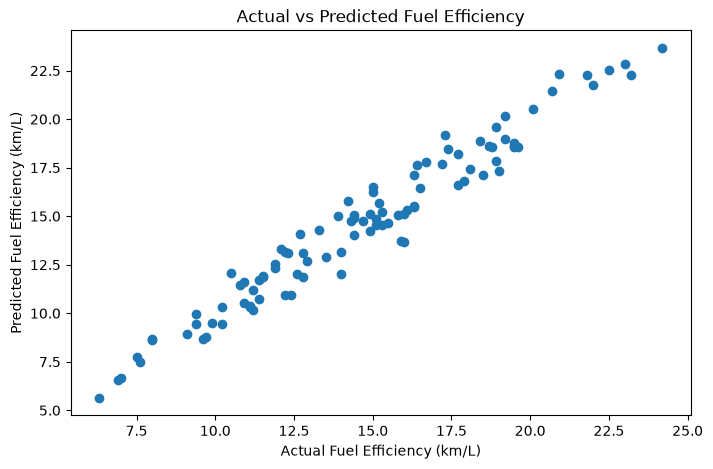

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Fuel Efficiency (km/L)")
plt.ylabel("Predicted Fuel Efficiency (km/L)")
plt.title("Actual vs Predicted Fuel Efficiency")

plt.show()

In [17]:
new_vehicle = pd.DataFrame({
    "Engine_Size_L": [1.5],
    "Weight_kg": [1100],
    "Cylinders": [4],
    "Horsepower_HP": [105],
    "Transmission": [1],
    "Vehicle_Age_Years": [2]
})

prediction = model.predict(new_vehicle)

print("Predicted Fuel Efficiency:",
      round(prediction[0], 2),
      "km/L")

Predicted Fuel Efficiency: 21.72 km/L
